<a href="https://colab.research.google.com/github/Jenil9825/ArecaEdge/blob/main/ArecaEdge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install opendatasets

In [4]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tejpaviraj/arecanut")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Jenil0023
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tejpaviraj/arecanut


100%|██████████| 7.45G/7.45G [01:39<00:00, 80.6MB/s]


In [5]:
pip install timm

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

In [7]:
class ArecanutDataset(Dataset):
  def __init__(self, data_dir, transform=None):
    self.data = ImageFolder(data_dir, transform=transform)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx]

    @property
    def classes(self):
      return self.data.classes

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

data_dir = './arecanut/Arecanut_dataset/Arecanut_dataset/train'

dataset = ArecanutDataset(data_dir, transform)

print("Dataset length:", len(dataset))

Dataset length: 8847


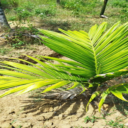

In [9]:
from torchvision.transforms.functional import to_pil_image

img_tensor, label = dataset[120]
to_pil_image(img_tensor)
# print(label)

In [10]:
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'Healthy_Leaf', 1: 'Healthy_Nut', 2: 'Healthy_Trunk', 3: 'Mahali_Koleroga', 4: 'Stem_bleeding', 5: 'bud borer', 6: 'healthy_foot', 7: 'stem cracking', 8: 'yellow leaf disease'}


In [11]:
image, label = dataset[1678]
image.shape

torch.Size([3, 128, 128])

In [12]:
for image, label in dataset:
  break

In [13]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [14]:
for images, labels in dataloader:
  break

In [15]:
images.shape, labels.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [16]:
labels

tensor([2, 3, 2, 3, 5, 8, 3, 8, 2, 2, 7, 3, 3, 3, 8, 3, 2, 2, 1, 8, 8, 1, 3, 3,
        7, 8, 7, 3, 3, 3, 1, 0])

In [17]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor()
])

In [18]:
train_folder = './arecanut/Arecanut_dataset/Arecanut_dataset/train/'
valid_folder = './arecanut/Arecanut_dataset/Arecanut_dataset/test'
test_folder = './arecanut/Arecanut_dataset/Arecanut_dataset/test'

train_dataset = ArecanutDataset(train_folder, transform=train_transforms)
test_dataset = ArecanutDataset(test_folder, transform=transform)
valid_dataset = ArecanutDataset(valid_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [19]:
class SimpleClassifier(nn.Module):
  def __init__(self, num_classes = len(train_dataset.data.classes)):
    super(SimpleClassifier, self).__init__()
    self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
    self.features = nn.Sequential(*list(self.base_model.children())[:-1])

    enet_out_size = 1280
    self.classifier = nn.Linear(enet_out_size, num_classes)

  def forward(self, x):
    x = self.features(x)
    output = self.classifier(x)
    return output

In [20]:
model = SimpleClassifier(num_classes=9)
print(str(model)[:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

SimpleClassifier(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)


In [21]:
ex_out = model(images)
ex_out.shape

torch.Size([32, 9])

In [22]:
criterion = nn.CrossEntropyLoss()

In [25]:

criterion(ex_out.to(device), labels.to(device))

tensor(2.1794, device='cuda:0', grad_fn=<NllLossBackward0>)

In [ ]:
num_epochs = 10
train_losses, valid_losses = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleClassifier(num_classes=9)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(train_loader, desc = 'Training loop'):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)

  model.eval()
  running_loss = 0.0
  with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc = 'Validation loop'):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      running_loss += loss.item()
    valid_loss = running_loss / len(valid_loader)
    valid_losses.append(valid_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {valid_loss}")


Training loop:   0%|          | 0/277 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 1/10 - Train loss: 0.20938312203374554, Validation loss: 0.17894273371930466


Training loop:   0%|          | 0/277 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 2/10 - Train loss: 0.07753983423717334, Validation loss: 0.16180541645693924


Training loop:   0%|          | 0/277 [00:00<?, ?it/s]

In [ ]:
print(device)